In [1]:
import datetime
import numpy as np
import pandas as pd
from scipy.io import loadmat
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def load_data(battery):
  mat = loadmat('E:/' + battery + '.mat')
  print('Total data in dataset: ', len(mat[battery][0, 0]['cycle'][0]))
  counter = 0
  dataset = []
  capacity_data = []

  for i in range(len(mat[battery][0, 0]['cycle'][0])):
    row = mat[battery][0, 0]['cycle'][0, i]
    if row['type'][0] == 'discharge':
      ambient_temperature = row['ambient_temperature'][0][0]
      date_time = datetime.datetime(int(row['time'][0][0]),
                               int(row['time'][0][1]),
                               int(row['time'][0][2]),
                               int(row['time'][0][3]),
                               int(row['time'][0][4])) + datetime.timedelta(seconds=int(row['time'][0][5]))
      data = row['data']
      capacity = data[0][0]['Capacity'][0][0]
      for j in range(len(data[0][0]['Voltage_measured'][0])):
        voltage_measured = data[0][0]['Voltage_measured'][0][j]
        current_measured = data[0][0]['Current_measured'][0][j]
        temperature_measured = data[0][0]['Temperature_measured'][0][j]
        current_load = data[0][0]['Current_load'][0][j]
        voltage_load = data[0][0]['Voltage_load'][0][j]
        time = data[0][0]['Time'][0][j]
        dataset.append([counter + 1, ambient_temperature, date_time, capacity,
                        voltage_measured, current_measured,
                        temperature_measured, current_load,
                        voltage_load, time])
      capacity_data.append([counter + 1, ambient_temperature, date_time, capacity])
      counter = counter + 1
  print(dataset[0])
  return [pd.DataFrame(data=dataset,
                       columns=['cycle', 'ambient_temperature', 'datetime',
                                'capacity', 'voltage_measured',
                                'current_measured', 'temperature_measured',
                                'current_load', 'voltage_load', 'time']),
          pd.DataFrame(data=capacity_data,
                       columns=['cycle', 'ambient_temperature', 'datetime',
                                'capacity'])]

In [3]:
dataset1, capacity1 = load_data('B0029')
dataset2, capacity2 = load_data('B0032')
dataset3, capacity3 = load_data('B0031')
dataset = pd.concat([dataset1, dataset2,dataset3], axis=0)
capacity = pd.concat([capacity1, capacity2,capacity3], axis=0)
capacity = capacity.reset_index(drop=True)
dataset = dataset.reset_index(drop=True)
pd.set_option('display.max_columns', 10)
print(dataset.head())
dataset.describe()

Total data in dataset:  97
[1, 43, datetime.datetime(2009, 4, 7, 16, 31, 1), 1.697507332205763, 4.122635846291491, -0.0006074349136117565, 43.41517780938604, 0.0004, 0.0, 0.0]
Total data in dataset:  97
[1, 43, datetime.datetime(2009, 4, 7, 16, 31, 1), 1.7048641073512139, 4.087016142066692, -0.0030060663936215554, 43.26523418326313, 0.0004, 0.0, 0.0]
Total data in dataset:  97
[1, 43, datetime.datetime(2009, 4, 7, 16, 31, 1), 1.6666751942525773, 4.116561748956975, -5.512929124633905e-05, 42.830036312976034, 0.0006, 0.0, 0.0]
   cycle  ambient_temperature            datetime  capacity  voltage_measured  \
0      1                   43 2009-04-07 16:31:01  1.697507          4.122636   
1      1                   43 2009-04-07 16:31:01  1.697507          4.122759   
2      1                   43 2009-04-07 16:31:01  1.697507          3.804544   
3      1                   43 2009-04-07 16:31:01  1.697507          3.779300   
4      1                   43 2009-04-07 16:31:01  1.697507     

,cycle,ambient_temperature,datetime,capacity,voltage_measured,current_measured,temperature_measured,current_load,voltage_load,time
count,19053.000000,19053.0,19053,19053.000000,19053.000000,19053.000000,19053.000000,19053.000000,19053.000000,19053.000000
mean,19.647300,43.0,2009-04-13 03:15:29.301684736,1.745402,3.387655,-3.906999,53.615363,3.908893,1.388063,808.943935
min,1.000000,43.0,2009-04-07 16:31:01,1.612080,1.800038,-4.029582,42.830036,0.000400,0.000000,0.000000
25%,10.000000,43.0,2009-04-09 22:58:17,1.695707,3.267239,-4.022963,50.615571,3.995000,1.252000,401.359000
50%,19.000000,43.0,2009-04-13 19:04:39,1.746293,3.376848,-3.990125,54.111418,3.997000,1.400000,808.438000
75%,30.000000,43.0,2009-04-16 03:06:43,1.788156,3.535530,-3.975190,56.891280,4.001000,1.548000,1215.109000
max,40.000000,43.0,2009-04-17 21:46:23,1.894032,4.207372,0.004550,62.969966,4.001000,4.223000,1723.281000
std,11.535193,0.0,NaN,0.060753,0.255873,0.589058,4.308466,0.588953,0.372765,470.914530


In [4]:
attrib=['cycle', 'datetime', 'capacity']
dis_ele = capacity[attrib]
C = dis_ele['capacity'][0]
for i in range(len(dis_ele)):
    dis_ele['SoH']=(dis_ele['capacity'])/C
print(dis_ele)

C = dataset['capacity'][0]
soh = []
for i in range(len(dataset)):
  soh.append([dataset['capacity'][i] / C])
soh = pd.DataFrame(data=soh, columns=['SoH'])

attribs=['capacity', 'voltage_measured', 'current_measured',
         'temperature_measured', 'current_load', 'voltage_load', 'time']
train_dataset = dataset[attribs]
sc = MinMaxScaler(feature_range=(0,1))
train_dataset = sc.fit_transform(train_dataset)
print(train_dataset.shape)
print(soh.shape)

     cycle            datetime  capacity       SoH
0        1 2009-04-07 16:31:01  1.697507  1.000000
1        2 2009-04-07 19:44:26  1.844701  1.086712
2        3 2009-04-07 22:58:18  1.825438  1.075364
3        4 2009-04-08 02:11:30  1.815750  1.069657
4        5 2009-04-08 05:23:26  1.813299  1.068213
..     ...                 ...       ...       ...
115     36 2009-04-17 09:45:34  1.695707  0.998939
116     37 2009-04-17 12:46:29  1.687697  0.994221
117     38 2009-04-17 15:46:53  1.681962  0.990842
118     39 2009-04-17 18:47:33  1.675003  0.986743
119     40 2009-04-17 21:46:23  1.667299  0.982204

[120 rows x 4 columns]
(19053, 7)
(19053, 1)


In [5]:
from sklearn.model_selection import train_test_split
X_train, X_valid, Y_train, Y_valid = train_test_split(train_dataset, soh, test_size=0.2, random_state=0)
print('Train set shape', X_train.shape)
print('Validation set shape', X_valid.shape)

Train set shape (15242, 7)
Validation set shape (3811, 7)


In [6]:

X_train_series = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_valid_series = X_valid.reshape((X_valid.shape[0], X_valid.shape[1], 1))
print('Train set shape', X_train_series.shape)
print('Validation set shape', X_valid_series.shape)

Train set shape (15242, 7, 1)
Validation set shape (3811, 7, 1)


In [7]:
from tensorflow.keras.layers import Dense, Dropout, Flatten, LSTM, Bidirectional, Conv1D, MaxPooling1D, Multiply,Input
from tensorflow.keras.models import Model
window=2
inputs=Input(shape=(X_train_series.shape[1], X_train_series.shape[2]))
model=Conv1D(filters = 64, kernel_size = 3, activation = 'relu')(inputs)
model=MaxPooling1D(pool_size = window)(model)
model=Dropout(0.3)(model)
model=Bidirectional(LSTM(100, activation='relu'), name='bilstm')(model)
attention=Dense(200, activation='sigmoid', name='attention_vec')(model)
model=Multiply()([model, attention])
outputs = Dense(1, activation='relu')(model)
model = Model(inputs=inputs, outputs=outputs)
model.compile(loss='mse',optimizer='adam',metrics=['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 7, 1)]       0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 5, 64)        256         ['input_1[0][0]']                
                                                                                                  
 max_pooling1d (MaxPooling1D)   (None, 2, 64)        0           ['conv1d[0][0]']                 
                                                                                                  
 dropout (Dropout)              (None, 2, 64)        0           ['max_pooling1d[0][0]']          
                                                                                              

In [11]:
AM_CNN_lstm_history = model.fit(X_train_series, Y_train, validation_data=(X_valid_series, Y_valid), epochs=30, verbose=2)

Epoch 1/30
477/477 - 4s - loss: 2.1173e-05 - accuracy: 0.0089 - val_loss: 4.9072e-04 - val_accuracy: 0.0087 - 4s/epoch - 8ms/step
Epoch 2/30
477/477 - 3s - loss: 1.6580e-05 - accuracy: 0.0089 - val_loss: 5.2768e-04 - val_accuracy: 0.0087 - 3s/epoch - 6ms/step
Epoch 3/30
477/477 - 3s - loss: 1.6698e-05 - accuracy: 0.0089 - val_loss: 4.4032e-04 - val_accuracy: 0.0087 - 3s/epoch - 6ms/step
Epoch 4/30
477/477 - 3s - loss: 1.5254e-05 - accuracy: 0.0089 - val_loss: 3.5392e-04 - val_accuracy: 0.0087 - 3s/epoch - 5ms/step
Epoch 5/30
477/477 - 3s - loss: 1.7709e-05 - accuracy: 0.0089 - val_loss: 6.2259e-04 - val_accuracy: 0.0087 - 3s/epoch - 6ms/step
Epoch 6/30
477/477 - 3s - loss: 1.3862e-05 - accuracy: 0.0089 - val_loss: 4.8773e-04 - val_accuracy: 0.0087 - 3s/epoch - 7ms/step
Epoch 7/30
477/477 - 5s - loss: 1.8024e-05 - accuracy: 0.0089 - val_loss: 4.9378e-04 - val_accuracy: 0.0087 - 5s/epoch - 11ms/step
Epoch 8/30
477/477 - 4s - loss: 1.3252e-05 - accuracy: 0.0089 - val_loss: 4.3613e-04 - va

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> TESTING
Total data in dataset:  97
[1, 43, datetime.datetime(2009, 4, 7, 16, 31, 1), 1.6560706096175404, 4.121227217169418, 0.00024592298559311063, 43.15149833518289, 0.0006, 0.0, 0.0]
   cycle  ambient_temperature            datetime  capacity  voltage_measured  \
0      1                   43 2009-04-07 16:31:01  1.656071          4.121227   
1      1                   43 2009-04-07 16:31:01  1.656071          4.121228   
2      1                   43 2009-04-07 16:31:01  1.656071          3.785855   
3      1                   43 2009-04-07 16:31:01  1.656071          3.760708   
4      1                   43 2009-04-07 16:31:01  1.656071          3.740429   

   current_measured  temperature_measured  current_load  voltage_load    time  
0          0.000246             43.151498        0.0006         0.000   0.000  
1          0.001759             43.152386        0.0006         4.137   9.359  
2         -4.023211             43.178

<Figure size 1000x600 with 0 Axes>

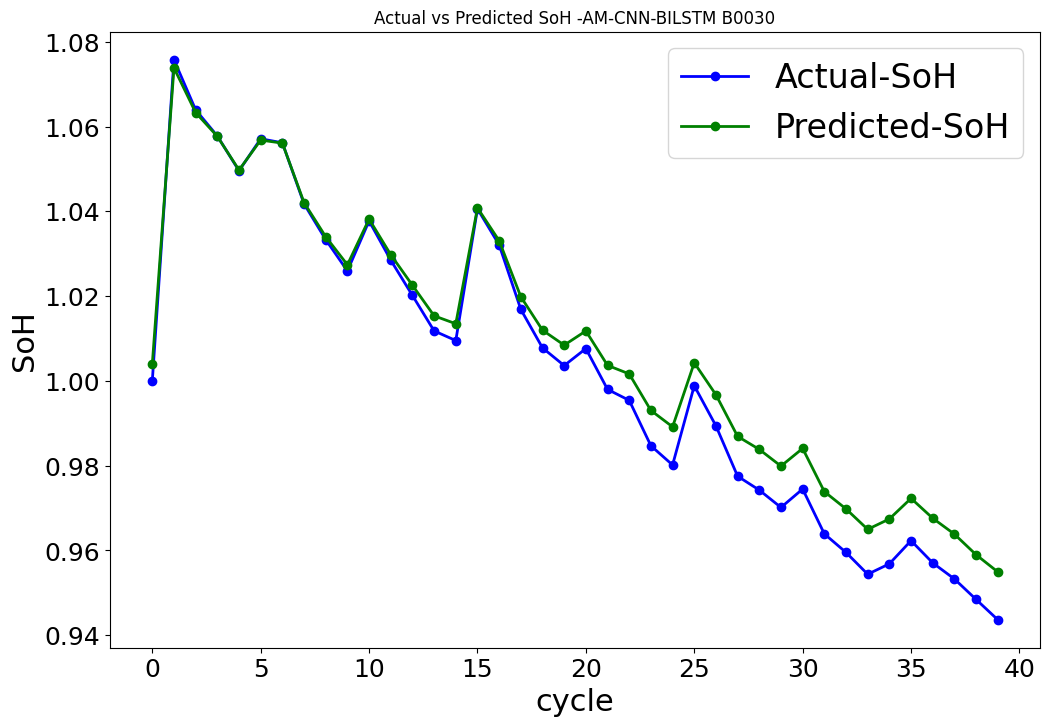

In [16]:
print(">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> TESTING")
dataset_val, capacity_val = load_data('B0030')
attrib=['cycle', 'datetime', 'capacity']
dis_ele = capacity_val[attrib]
C = dis_ele['capacity'][0]
for i in range(len(dis_ele)):
    dis_ele['SoH']=(dis_ele['capacity']) / C
print(dataset_val.head(5))
print(dis_ele.head(5))
attrib=['capacity', 'voltage_measured', 'current_measured',
        'temperature_measured', 'current_load', 'voltage_load', 'time']
soh_pred =  model.predict(sc.fit_transform(dataset_val[attrib]))
print(soh_pred.shape)
print(">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>.ACTUAL AND PREDICTED SOH")
C = dataset_val['capacity'][0]
soh = []
for i in range(len(dataset_val)):
  soh.append(dataset_val['capacity'][i] / C)
new_soh = dataset_val.loc[(dataset_val['cycle'] >= 1), ['cycle']]
new_soh['SoH'] =  soh
new_soh['NewSoH'] = soh_pred
new_soh = new_soh.groupby(['cycle']).mean().reset_index()
print(new_soh.head(10))
rms = np.sqrt(mean_squared_error(new_soh['SoH'], new_soh['NewSoH']))
print('Root Mean Square Error: ', rms)
# Calculate Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((new_soh['SoH'] - new_soh['NewSoH']) / new_soh['SoH'])) * 100
print("Mean Absolute Percentage Error (MAPE):", mape)
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(new_soh['SoH'], new_soh['NewSoH'])
print("Mean Squared Error (MSE):", mse)
mae = mean_absolute_error(new_soh['SoH'], new_soh['NewSoH'])
print(f'Mean Absolute Error (MAE): {mae:.4f}')
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
# Tracer les valeurs réelles vs les valeurs prédites
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots(1, figsize=(12, 8))
plt.plot(new_soh['SoH'], color='blue', linewidth=2, label='Actual-SoH', marker='o')
plt.plot(new_soh['NewSoH'], color='green', linewidth=2, label='Predicted-SoH', marker='o')
ax.set_xlabel('cycle', fontsize=22)  # Taille de police de l'axe des abscisses
ax.set_ylabel('SoH', fontsize=22)       # Taille de police de l'axe des ordonnées
ax.set_title('Actual vs Predicted SoH -AM-CNN-BILSTM B0030')
ax.tick_params(axis='x', which='major', labelsize=18)  # Taille des hachures des axes des abscisses
ax.tick_params(axis='y', which='major', labelsize=18)  # Taille des hachures des axes des ordonnées
# Légende
plt.legend(fontsize=24)

plt.show()

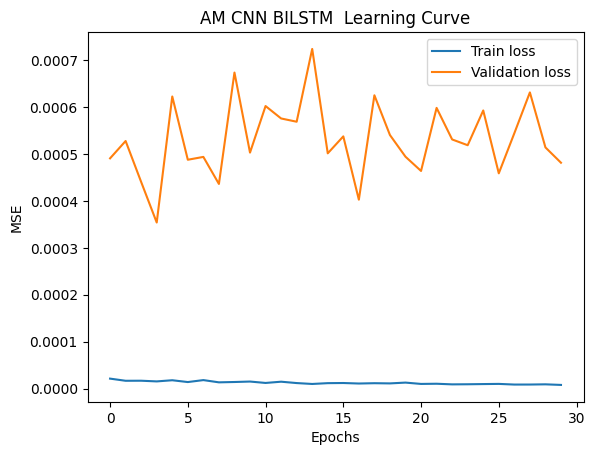

In [13]:
import matplotlib.pyplot as plt
plt.plot(AM_CNN_lstm_history.history['loss'], label='Train loss')
plt.plot(AM_CNN_lstm_history.history['val_loss'], label='Validation loss')
plt.legend(loc='best')
plt.title('AM CNN BILSTM  Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.show()

In [14]:
model.save('AM CNN BILSTM30.h5')
# Chargement
from keras.models import load_model
model = load_model('AM CNN BILSTM30.h5')